# 第 12 天：Demo Day 与研究成果包

把策略、轨迹、分数、机制解释和失败分析整理成可展示的最终成果。

最后一天不是只展示最高分，而是展示一条完整科学链：问题、策略、证据、解释、局限和下一步。


## 学习路径定位

| 项目 | 内容 |
| --- | --- |
| 阶段 | D. 接近科研评测 |
| 难度 | 综合挑战 |
| 先修 | 已有 public/private 结果、轨迹、解释和验证日志。 |
| 今天只解决 | 形成最终展示：性能、机理、安全、泛化和复现性并重。 |
| 今天不要求 | 不做营销式展示；每个结论都要有实验或日志证据。 |
| 本日交付 | Demo Day 报告骨架、项目摘要、关键图表和可复现证据。 |
| 下一步如何复用 | Day 13 会把同一套世界规律扩展到更多化工过程。 |



## 课堂时间盒：每 30 分钟都有产出

建议按 3 小时工作坊使用。每一段都要留下一个小证据，不要只运行代码看到结果就继续往下翻。

| 时间 | 阶段目标 | 具体动作 | 当段产出 |
| --- | --- | --- | --- |
| 0:00-0:30 | 整理故事线 | 确定问题、策略、证据、结果、局限。 | 形成展示大纲。 |
| 0:30-1:00 | 复查数据链 | 确认 trajectory、results、figures、explanation 都存在。 | 补齐缺失文件。 |
| 1:00-1:30 | 制作性能页 | 展示 score、risk、cost、efficiency。 | 得到性能图表。 |
| 1:30-2:00 | 制作机制页 | 展示扫描、谱图或 surrogate 证据。 | 得到机制解释页。 |
| 2:00-2:30 | 制作可复现页 | 展示命令、manifest、verify 结果。 | 得到复现说明。 |
| 2:30-3:00 | 演示排练 | 用 3 分钟讲完科学闭环。 | 形成最终 demo script。 |

教师提示：如果课堂时间少于 3 小时，可以把最后两个时间盒改成课后提交；但前四个时间盒建议现场完成。


## 本日任务梯度

| 层级 | 任务 |
| --- | --- |
| 基础任务 | 整理一页项目摘要和关键结果表。 |
| 进阶任务 | 把机制解释、失败分析和下一步实验写成连贯故事。 |
| 挑战任务 | 设计一个对外评审也能复现的 paper artifact 清单。 |
| 反思问题 | 你的结果最可信的证据是什么？最大的不确定性又是什么？ |



## 三小时实验工单（必须自己完成）

这一节不是演示输出，而是当天真正的工作量。请不要只从上到下运行已有单元；必须在后面的学生工作区新增自己的实验、图表、表格和文字结论。

| 序号 | 最小完成量 |
| --- | --- |
| 1 | 整理最终 6 类证据：轨迹、榜单、图表、机理解释、失败分析、复现命令。 |
| 2 | 形成 8-10 页展示稿或等价 markdown 报告。 |
| 3 | 至少选择 1 条最佳轨迹和 1 条失败轨迹进行并排解释。 |
| 4 | 写 800 字最终结论：你发现了什么局部 world model，下一步如何验证。 |

验收口径：本日交付至少应包含数据表、图或谱图、验证/评测结果、机制解释和下一步实验建议。低于这些证据量，视为只完成了演示浏览。



## 学生工作区

请从这里开始写自己的实验扩展。建议保留上方演示单元作为参考，不要直接覆盖；把你新增的实验条件、图、模型、验证结果和文字结论放在下面。

建议你在本节下面新增自己的代码单元。可从这个记录模板开始：

```python
student_work = {
    "hypothesis": "",
    "experiments_added": 0,
    "figures_created": 0,
    "verification_or_metric": "",
    "next_experiment": "",
}
```



In [1]:
import importlib
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "notebooks" / "tutorials"))

tu = importlib.import_module("tutorial_utils")

pd.set_option("display.precision", 4)
OUTPUT_DIR = tu.ensure_output(12)
print("project root:", ROOT)
print("output dir:", OUTPUT_DIR)

project root: D:\Projects\ChemWorld
output dir: D:\Projects\ChemWorld\runs\tutorials\day12


## 今日任务

请先运行顶部导入单元，确认 kernel 指向项目虚拟环境；随后按顺序执行每个代码单元，观察表格、图形和验证结果，并在最后写下自己的实验判断。


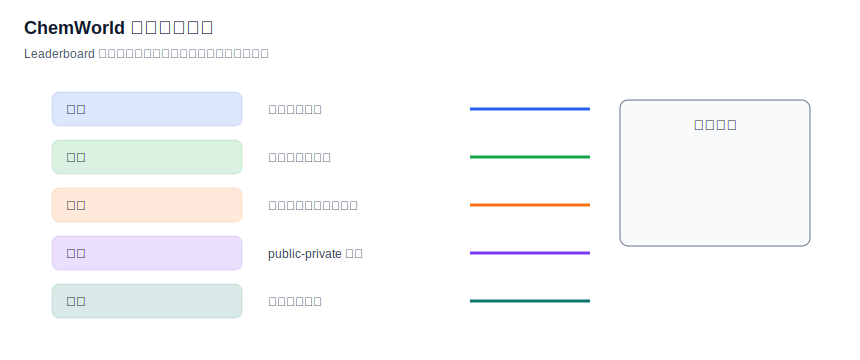

In [2]:
tu.display_tutorial_header(
    day=12,
    title='Demo Day 与研究成果包',
    subtitle='把策略、轨迹、分数、机制解释和失败分析整理成可展示的最终成果。',
    focus=[
        '最终 artifact',
        '机制评分 rubric',
        '综合得分',
        '展示摘要',
    ],
    deliverables=[
        '一份 artifact JSON',
        '一份机制解释',
        '一页 demo day 摘要',
    ],
    project_link='12 天课程的最终产物应接近一个小型 benchmark paper artifact。',
)
tu.display_course_map(12)
display(tu.leaderboard_blueprint_svg())


In [3]:
tu.display_api_card()

## 第 12 天检查点

完成本 notebook 后，请确认你已经留下这些证据：

- 一份 final artifact JSON
- 一个机制解释分数
- 一个综合 capstone 分数
- 一页 demo-day 摘要


In [5]:
from chemworld.data.logging import load_jsonl
from chemworld.eval.explanations import combined_artifact_score, score_mechanism_explanation
from chemworld.eval.metrics import evaluate_records
from chemworld.eval.verify import verify_records

source = ROOT / "runs" / "tutorials" / "day07" / "best_candidate_capstone.jsonl"
if not source.exists():
    fallback_recipe = {
        "temperature": 75.0,
        "time": 0.50,
        "initial_concentration": 0.35,
        "stirring_speed": 650.0,
        "catalyst": 1,
        "solvent": 1,
    }
    records = tu.write_recipe_trajectory(
        fallback_recipe,
        source,
        split="public-test",
        seed=77,
        agent_name="demo_day_fallback",
    )
else:
    records = load_jsonl(source)

evaluation = evaluate_records(records).to_dict()
verification = verify_records(records).to_dict()
tu.show_json_panel("Evaluation", evaluation)
tu.show_json_panel("Verification", verification)

In [6]:
explanation = {
    "hypothesis": (
        "Moderate temperature improves conversion while avoiding high-temperature degradation."
    ),
    "learned_mechanism": (
        "Yield is limited by degradation, byproduct formation, and "
        "catalyst-solvent interactions that affect selectivity."
    ),
    "safety": (
        "Higher concentration and hotter operation increase risk, so a lower-risk "
        "solvent and moderate loading are preferred."
    ),
    "limitations": (
        "The result is seed-limited and uncertain; public-test success may not "
        "generalize to private-eval."
    ),
    "next_experiment": (
        "Run a local validation design around the selected recipe with one "
        "UV-vis mid-run measurement."
    ),
}
mechanism = score_mechanism_explanation(explanation).to_dict()
tu.show_json_panel("Mechanism explanation", explanation)
tu.show_json_panel("Rubric score", mechanism)

In [7]:
import json

is_reproducible = bool(verification.get("verified", verification.get("ok", False)))
artifact_score = combined_artifact_score(
    performance=float(evaluation["total_score"]),
    mechanism_score=float(mechanism["normalized"]),
    reproducibility=1.0 if is_reproducible else 0.0,
)
summary = {
    "artifact_score": artifact_score,
    "evaluation_total_score": evaluation["total_score"],
    "mechanism_score": mechanism["normalized"],
    "reproducible": is_reproducible,
    "best_score": evaluation["final_best_score"],
    "safety_aware_score": evaluation["safety_aware_score"],
    "required_next_step": (
        "Run the strategy over public-test and private-eval with at least 30 seeds "
        "before making benchmark claims."
    ),
}
summary_path = OUTPUT_DIR / "demo_day_summary.json"
summary_path.write_text(
    json.dumps(summary, indent=2, sort_keys=True) + "\n",
    encoding="utf-8",
)
tu.show_json_panel("Demo Day summary artifact", summary)
print(f"Wrote {summary_path.relative_to(ROOT)}")

Wrote runs\tutorials\day12\demo_day_summary.json


,dimension,value
0,performance,0.3758
1,mechanism,0.8571
2,reproducibility,1.0000
3,combined,0.6451


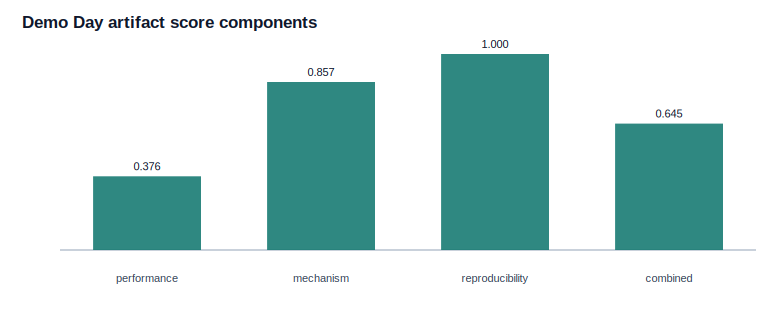

In [8]:
presentation_df = pd.DataFrame(
    [
        {"dimension": "performance", "value": evaluation["total_score"]},
        {"dimension": "mechanism", "value": mechanism["normalized"]},
        {"dimension": "reproducibility", "value": 1.0 if is_reproducible else 0.0},
        {"dimension": "combined", "value": artifact_score},
    ]
)
display(presentation_df)
display(
    tu.bar_svg(
        presentation_df["dimension"].tolist(),
        presentation_df["value"].astype(float).tolist(),
        title="Demo Day artifact score components",
        color="#0f766e",
    )
)

## 课后反思

请用两三句话回答下面的问题，并把答案写进当天的实验日志。


In [9]:
tu.display_reflection_box(
    [
        '你的最终策略最强的证据是什么？',
        '如果再给一周，你会优先改进哪一部分？',
    ]
)
